In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.utils import resample

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')


from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.base import clone


In [ ]:
# Pulling in the data
df = pd.read_csv('../data/dataset_final.csv')

display(df.head(3))

,Unnamed: 0,zpid,address,price,beds,baths,area_sqft,latitude,longitude,status,...,state_name,county_lookup,state_median_housing_value,state_median_prop_tax_rate,med_prop_tax_paid,single_filer_rates,single_filer_brackets,married_filing_jointly_rates,married_filing_jointly_brackets,state_avg_median_income
0,0,17264897,"979 Kevin Ave, Redlands, CA 92373",447000,3.0,2.0,1300.0,34.040520,-117.186195,House for sale,...,California,San Bernardino County,481100.0,0.69,3293.5,0.093,72724.0,0.093,145448.0,98741.5
1,1,20021372,"13114 Addison St, Sherman Oaks, CA 91423",2795000,4.0,5.0,2900.0,34.160885,-118.418770,House for sale,...,California,Los Angeles County,481100.0,0.69,3293.5,0.093,72724.0,0.093,145448.0,98741.5
2,2,20009320,"6032 Goodland Ave, North Hollywood, CA 91606",1718000,4.0,3.0,3025.0,34.180450,-118.411280,House for sale,...,California,Los Angeles County,481100.0,0.69,3293.5,0.093,72724.0,0.093,145448.0,98741.5


##### Intercept Only Model

In [15]:
# setting response variable
y = df['price']

# setting an array of ones to same number of rows in the master dataset
X = np.ones((len(df), 1))

# fitting the model with the intercept only
model = LinearRegression().fit(X, y)
print(f"Intercept: {model.intercept_}")

# validating
intercept = df['price'].mean()
print(f"Correct Intercept: {intercept}")

Intercept: 1372109.4021894336
Correct Intercept: 1372109.4021894336


##### Lasso & Ridge Models

In [16]:
# Filtering the dataframe to only have houses that can  be purchased
print('======Before======')
print(df['status'].value_counts())

pre_status_drop = df['status'].shape[0]
print(f'There are {pre_status_drop} rows in the status column')

drop_vals = ['Foreclosure', 'Auction']
df_filtered = df[~df['status'].isin(drop_vals)].copy()

print()
print('======After======')
print(df_filtered['status'].value_counts())
# Checking how many null values
df_filtered.isnull().sum()
# Using the median for null values in area_sqft
df_filtered["area_sqft"] = df_filtered["area_sqft"].fillna(
    df_filtered["area_sqft"].median()
)
# Only had 1 null in longitude and latitude so decided to drop it
df_filtered = df_filtered.dropna(subset=["latitude", "longitude"])
df_filtered.isnull().sum()

post_status_drop = df_filtered['status'].shape[0]
print(f'Number of rows removed: {pre_status_drop - post_status_drop}')
print(f'There are {post_status_drop} rows in the status column')

print()
print(f'Null values remaining: {df_filtered.isnull().sum()[df_filtered.isnull().sum() > 0]}')



======Before======
status
House for sale           1447
Active                    350
Coming soon               219
Condo for sale             18
Townhouse for sale         14
Active Under Contract      14
New construction           13
Foreclosure                11
For sale by owner           8
Auction                     3
Coming Soon                 3
New                         1
Name: count, dtype: int64
There are 2101 rows in the status column

======After======
status
House for sale           1447
Active                    350
Coming soon               219
Condo for sale             18
Townhouse for sale         14
Active Under Contract      14
New construction           13
For sale by owner           8
Coming Soon                 3
New                         1
Name: count, dtype: int64
Number of rows removed: 15
There are 2086 rows in the status column

Null values remaining: zestimate    1037
dtype: int64


In [17]:
df_filtered.describe()

,Unnamed: 0,zpid,price,beds,baths,area_sqft,latitude,longitude,days_on_zillow,zestimate,zipcode,state_median_housing_value,state_median_prop_tax_rate,med_prop_tax_paid,single_filer_rates,single_filer_brackets,married_filing_jointly_rates,married_filing_jointly_brackets,state_avg_median_income
count,2086.000000,2.086000e+03,2.086000e+03,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,1.049000e+03,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2086.00000
mean,1083.254554,1.599796e+08,1.379320e+06,3.692234,2.939358,2718.970757,39.449264,-92.950196,23.569990,7.121868e+05,50797.402685,261450.167785,0.887876,2548.499760,0.046560,32133.702301,0.046089,52845.736817,88244.03104
std,627.826462,3.662249e+08,8.791477e+06,1.226880,1.694763,2805.578148,4.588989,16.053745,61.740531,1.566842e+06,30649.240055,106227.342123,0.506130,2011.530458,0.025576,33161.608139,0.025332,61693.602828,13391.64951
min,0.000000,8.239400e+04,3.550000e+04,1.000000,1.000000,572.000000,26.391940,-124.097000,-1.000000,2.920000e+04,1756.000000,134650.000000,0.280000,481.000000,0.000000,0.000000,0.000000,0.000000,65850.75000
25%,526.250000,2.290783e+07,3.382500e+05,3.000000,2.000000,1674.000000,36.001588,-105.073595,2.000000,3.468000e+05,25414.000000,169250.000000,0.520000,1134.000000,0.044000,0.000000,0.044000,0.000000,78990.25000
50%,1093.500000,5.321515e+07,4.950000e+05,4.000000,3.000000,2206.000000,39.601343,-90.639868,4.000000,4.905000e+05,55304.000000,231900.000000,0.690000,1888.000000,0.050000,26050.000000,0.050000,26050.000000,83007.25000
75%,1628.750000,1.149182e+08,7.600000e+05,4.000000,3.000000,2929.000000,42.769367,-78.822317,9.000000,7.355000e+05,78037.500000,335600.000000,1.070000,3293.500000,0.063700,60000.000000,0.060000,82500.000000,99511.75000
max,2158.000000,2.134250e+09,3.000000e+08,18.000000,27.000000,50000.000000,48.790657,-69.429490,745.000000,4.079420e+07,99362.000000,587550.000000,2.030000,8055.000000,0.093000,100000.000000,0.093000,200000.000000,114341.75000


In [18]:
#Trying to get rid of extreme outliers on both the low and high ends of prices

# Minimum should be $35,500 but this is left as a safety
df_filtered = df_filtered[df_filtered['price'] > 10000]

cap = df_filtered['price'].quantile(0.99)
print(f"Capping at: ${cap:,.0f}")
df_filtered = df_filtered[df_filtered['price'] <= cap]

print(f"Rows remaining: {len(df_filtered)}")
print(df_filtered['price'].describe())

Capping at: $22,560,000
Rows remaining: 2065
count    2.065000e+03
mean     7.704434e+05
std      1.470751e+06
min      3.550000e+04
25%      3.350000e+05
50%      4.899000e+05
75%      7.500000e+05
max      2.250000e+07
Name: price, dtype: float64


In [19]:
'''
List of Columns for feature engineering
Index(['Unnamed: 0', 'zpid', 'address', 'price', 'beds', 'baths', 'area_sqft',
       'latitude', 'longitude', 'status', 'home_type', 'days_on_zillow',
       'zestimate', 'detail_url', 'has_open_house', 'is_featured',
       'street_add', 'city', 'state_zipcode', 'state_code', 'zipcode',
       'state_name', 'county_lookup', 'state_median_housing_value',
       'state_median_prop_tax_rate', 'med_prop_tax_paid', 'single_filer_rates',
       'single_filer_brackets', 'married_filing_jointly_rates',
       'married_filing_jointly_brackets', 'state_avg_median_income'],
      dtype='object')
'''

"\nList of Columns for feature engineering\nIndex(['Unnamed: 0', 'zpid', 'address', 'price', 'beds', 'baths', 'area_sqft',\n       'latitude', 'longitude', 'status', 'home_type', 'days_on_zillow',\n       'zestimate', 'detail_url', 'has_open_house', 'is_featured',\n       'street_add', 'city', 'state_zipcode', 'state_code', 'zipcode',\n       'state_name', 'county_lookup', 'state_median_housing_value',\n       'state_median_prop_tax_rate', 'med_prop_tax_paid', 'single_filer_rates',\n       'single_filer_brackets', 'married_filing_jointly_rates',\n       'married_filing_jointly_brackets', 'state_avg_median_income'],\n      dtype='object')\n"

**We elected to use log during training to improve relative error scaling in comparison to absolute error scaling**

**Ex. $2m home with 200k error is 10% off while $500k home with 200k error is 40% off**

In [20]:
# Dropping columns that are redundant or unhelpful
# Not sure if I should include zestimate, is_featured, and has_opened_house
# Also not sure about zipcode, city, and state name because they are string and if you one hot encode it would be a lot of columns
features = ['beds', 'baths', 'area_sqft', 'latitude', 'longitude', 'home_type',
            'days_on_zillow', 'state_median_housing_value', 'state_median_prop_tax_rate',
            'med_prop_tax_paid', 'state_code']
target = 'price'

RANDOM_STATE = 42

X = df_filtered[features]

# Adding dummy variables for one-hot encoding
X = pd.get_dummies(X, columns=["home_type", "state_code"], drop_first=True)

# Changing the target outcome to be between 0 and 1
y = np.log(df_filtered[target])

# Splitting the data with 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [21]:
# Confirming no underlying issues with the train/test datasets post-cleaning
train_df = X_train.copy()
test_df = X_test.copy()

train_df["price"] = y_train
test_df["price"] = y_test

print("=====TRAIN SUMMARY=====")
display(train_df.describe())

print("=====TEST SUMMARY=====")
display(test_df.describe())

=====TRAIN SUMMARY=====


,beds,baths,area_sqft,latitude,longitude,days_on_zillow,state_median_housing_value,state_median_prop_tax_rate,med_prop_tax_paid,price
count,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000
mean,3.637409,2.838983,2529.863801,39.464291,-92.728468,21.327482,261310.169492,0.894192,2571.974879,13.156393
std,1.076653,1.245019,1705.541291,4.600150,16.017718,55.786865,105585.079224,0.506576,2028.996455,0.721837
min,1.000000,1.000000,572.000000,26.391940,-124.039010,-1.000000,134650.000000,0.280000,481.000000,10.477288
25%,3.000000,2.000000,1670.000000,36.021751,-105.049796,2.000000,169250.000000,0.520000,1134.000000,12.721886
50%,4.000000,3.000000,2206.000000,39.642481,-90.542760,4.000000,231900.000000,0.690000,1888.000000,13.101957
75%,4.000000,3.000000,2886.500000,42.801018,-78.606965,9.000000,335600.000000,1.070000,3293.500000,13.527828
max,17.000000,14.000000,29087.000000,48.790657,-69.429490,745.000000,587550.000000,2.030000,8055.000000,16.929026


=====TEST SUMMARY=====


,beds,baths,area_sqft,latitude,longitude,days_on_zillow,state_median_housing_value,state_median_prop_tax_rate,med_prop_tax_paid,price
count,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000
mean,3.690073,2.877724,2563.815981,39.385927,-93.539261,22.871671,260734.019370,0.863765,2453.645278,13.177695
std,1.106391,1.405671,1639.820512,4.512633,16.096671,58.668441,109029.783714,0.505788,1965.765368,0.776309
min,1.000000,1.000000,634.000000,29.214384,-124.097000,0.000000,146400.000000,0.280000,481.000000,11.225243
25%,3.000000,2.000000,1658.000000,35.923950,-105.070450,2.000000,169250.000000,0.460000,921.000000,12.718597
50%,4.000000,3.000000,2206.000000,39.526510,-92.257900,4.000000,204700.000000,0.690000,1888.000000,13.093964
75%,4.000000,3.000000,2904.000000,42.028996,-80.871550,10.000000,390250.000000,1.070000,3293.500000,13.527827
max,10.000000,12.000000,16936.000000,48.719875,-72.035515,572.000000,481100.000000,2.030000,8055.000000,16.810993


**The previous output (directly above) shows the expected summary statistics and similar data for the train/test splits**

In [22]:
# Scaling the data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

alphas = np.logspace(-3, 6, 200)
alphas

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_sc, y_train)

print("Best alpha (Ridge):", ridge.alpha_)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso.fit(X_train_sc, y_train)

print("Best alpha (Lasso):", lasso.alpha_)

Best alpha (Ridge): 69.0551352016233
Best alpha (Lasso): 0.002072921779595372


In [23]:
# NEW
for name, model in [('Lasso', lasso), ('Ridge', ridge)]:
    y_pred_test_log = model.predict(X_test_sc)
    y_pred_train_log = model.predict(X_train_sc)

    # log metrics
    mse_test_log  = mean_squared_error(y_test, y_pred_test_log)
    mse_train_log  = mean_squared_error(y_train, y_pred_train_log)

    mae_test_log = mean_absolute_error(y_test, y_pred_test_log)
    mae_train_log = mean_absolute_error(y_train, y_pred_train_log)

    r2_test   = r2_score(y_test, y_pred_test_log)
    r2_train   = r2_score(y_train, y_pred_train_log)

    # convert log metrics back to dollars
    y_test_price = np.exp(y_test)
    y_train_price = np.exp(y_train)

    y_pred_test_price = np.exp(y_pred_test_log)
    y_pred_train_price = np.exp(y_pred_train_log)

    # dollar-space metrics
    mse_test_price = mean_squared_error(y_test_price, y_pred_test_price)
    mse_train_price = mean_squared_error(y_train_price, y_pred_train_price)

    mae_test_price = mean_absolute_error(y_test_price, y_pred_test_price)
    mae_train_price = mean_absolute_error(y_train_price, y_pred_train_price)

    r2_test_price = r2_score(y_test_price, y_pred_test_price)
    r2_train_price = r2_score(y_train_price, y_pred_train_price)

    print(f"\n{name}")

    print('Log Metrics:')
    print(f"  Train MSE: {mse_train_log:.4f} | Test MSE: {mse_test_log:.4f}")
    print(f"  Train MAE: {mae_train_log:.4f} | Test MAE: {mae_test_log:.4f}")
    print(f"  Train R2:  {r2_train:.4f} | Test R2:  {r2_test:.4f}")

    print('Dollar Metrics:')
    print(f"    Train MSE: ${mse_train_price:,.2f} | Test MSE: ${mse_test_price:,.2f}")
    print(f"    Train MAE: ${mae_train_price:,.2f} | Test MAE: ${mae_test_price:,.2f}")
    print(f"    Train R2:  {r2_train_price:.4f} | Test R2:  {r2_test_price:.4f}")

# Finding out which coefficients had the bigger impact
feature_names = X.columns
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

lasso_sorted = lasso_coefs.reindex(
    lasso_coefs.abs().sort_values(ascending=False).index
)
ridge_coefs = pd.Series(ridge.coef_, index=feature_names)

ridge_sorted = ridge_coefs.reindex(
    ridge_coefs.abs().sort_values(ascending=False).index
)



Lasso
Log Metrics:
  Train MSE: 0.2060 | Test MSE: 0.2231
  Train MAE: 0.3299 | Test MAE: 0.3426
  Train R2:  0.6045 | Test R2:  0.6289
Dollar Metrics:
    Train MSE: $5,641,193,274,178.27 | Test MSE: $1,617,234,868,085.58
    Train MAE: $346,617.27 | Test MAE: $331,796.68
    Train R2:  -1.6108 | Test R2:  0.2529

Ridge
Log Metrics:
  Train MSE: 0.2064 | Test MSE: 0.2246
  Train MAE: 0.3295 | Test MAE: 0.3436
  Train R2:  0.6036 | Test R2:  0.6265
Dollar Metrics:
    Train MSE: $5,255,871,873,047.45 | Test MSE: $1,575,309,786,123.78
    Train MAE: $343,767.53 | Test MAE: $332,202.56
    Train R2:  -1.4324 | Test R2:  0.2723


In [24]:
# original
for name, model in [('Lasso', lasso), ('Ridge', ridge)]:
    y_pred_test = model.predict(X_test_sc)
    y_pred_train = model.predict(X_train_sc)
    mse_test  = mean_squared_error(y_test, y_pred_test)
    mse_train  = mean_squared_error(y_train, y_pred_train)
    rmse_test = np.sqrt(mse_test)
    rmse_train = np.sqrt(mse_train)
    r2_test   = r2_score(y_test, y_pred_test)
    r2_train   = r2_score(y_train, y_pred_train)
    print(f"\n{name}")
    print(f"  Train MSE: {mse_train:.4f} | Test MSE: {mse_test:.4f}")
    print(f"  Train RMSE: {rmse_train:.4f} | Test RMSE: {rmse_test:.4f}")
    print(f"  Train R2:  {r2_train:.4f} | Test R2:  {r2_test:.4f}")

# Finding out which coefficients had the bigger impact
feature_names = X.columns
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

lasso_sorted = lasso_coefs.reindex(
    lasso_coefs.abs().sort_values(ascending=False).index
)
ridge_coefs = pd.Series(ridge.coef_, index=feature_names)

ridge_sorted = ridge_coefs.reindex(
    ridge_coefs.abs().sort_values(ascending=False).index
)


Lasso
  Train MSE: 0.2060 | Test MSE: 0.2231
  Train RMSE: 0.4538 | Test RMSE: 0.4723
  Train R2:  0.6045 | Test R2:  0.6289

Ridge
  Train MSE: 0.2064 | Test MSE: 0.2246
  Train RMSE: 0.4543 | Test RMSE: 0.4739
  Train R2:  0.6036 | Test R2:  0.6265


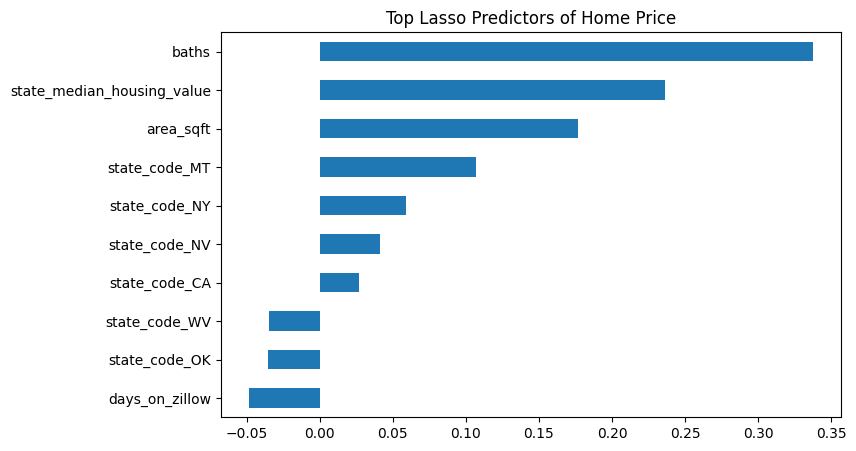

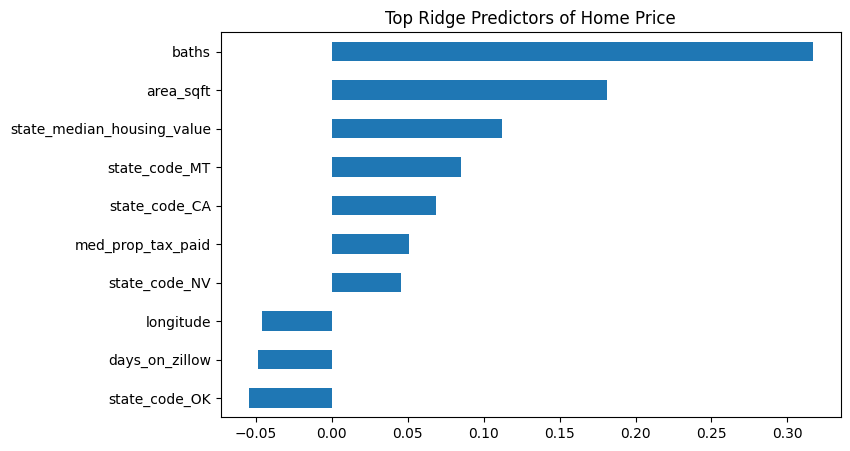

In [25]:
# Visualizations for Lasso coefficients
top_lasso = lasso_sorted
top_10_lasso = top_lasso.reindex(top_lasso.abs().sort_values(ascending=False).head(10).index)

plt.figure(figsize=(8,5))
top_10_lasso.sort_values().plot(kind="barh")
plt.title("Top Lasso Predictors of Home Price")
plt.show()

# Visualizations for Ridge (probably not super necessary but just good to compare to )
top_ridge = ridge_sorted
top_10_ridge = ridge_sorted.reindex(top_ridge.abs().sort_values(ascending=False).head(10).index)

plt.figure(figsize=(8,5))
top_10_ridge.sort_values().plot(kind="barh")
plt.title("Top Ridge Predictors of Home Price")
plt.show()

#### Decision Trees

Number of Features: 43
Best Decision Tree Parameters: {'ccp_alpha': 0.001, 'max_depth': 9, 'min_samples_leaf': 8}
Best CV MSE (log price) 0.23329968609129784


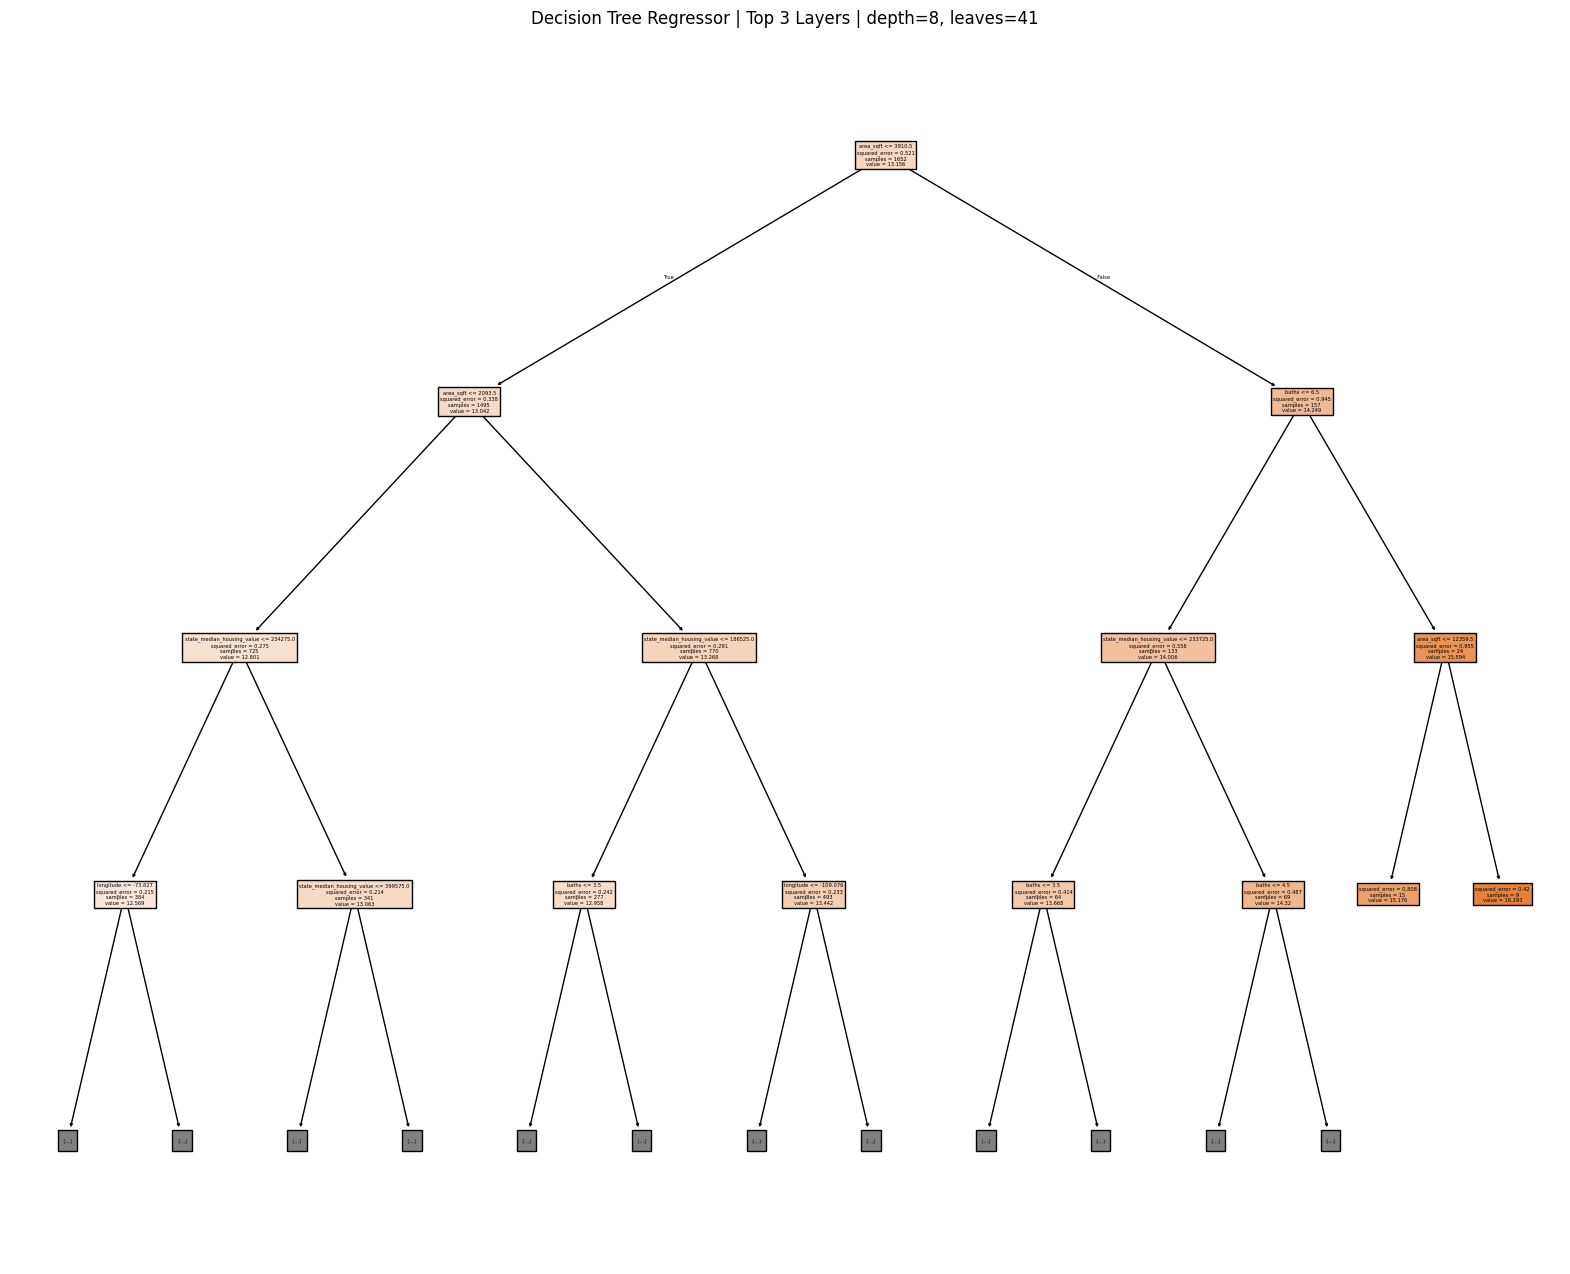

In [26]:
# copy predictors from X_train

random_state = RANDOM_STATE
PREDICTORS = list(X_train.columns)
print(f'Number of Features: {len(PREDICTORS)}')

# param sweep for dt model
# if not included, train MSE/MAE overfits to $0
dt_param_grid = {
    'max_depth': [1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, None],
    'min_samples_leaf': [1, 2, 3, 5, 8, 10, 12, 15, 18, 20, 25],
    'ccp_alpha': [0, 0.00001, 0.00005, 0.0001, 0.0005, 0.001, 0.0025, 0.005, 0.01, 0.025, 0.050, 0.10],
}

dt_grid_search = (
    GridSearchCV(
        estimator = DecisionTreeRegressor(random_state=random_state),
        param_grid = dt_param_grid,
        cv = 5,
        scoring = 'neg_mean_squared_error',
        n_jobs = 1
    )
)

dt_grid_search.fit(X_train[PREDICTORS], y_train)

# best model
dt_best_model = dt_grid_search.best_estimator_
# best params
dt_best_params = dt_grid_search.best_params_
# cv score
dt_best_cv = dt_grid_search.best_score_

print(f'Best Decision Tree Parameters: {dt_best_params}')
print(f'Best CV MSE (log price) {-dt_best_cv}')


fig = plt.figure(figsize=(20,16))
tree.plot_tree(dt_best_model, feature_names=PREDICTORS, filled=True, max_depth=3)
plt.title(f'Decision Tree Regressor | Top 3 Layers | depth={dt_best_model.get_depth()}, leaves={dt_best_model.get_n_leaves()}')
plt.show()

In [28]:
# Same metrics, now using dt_best instead of dt_single
y_pred_train_dt = dt_best_model.predict(X_train[PREDICTORS])
y_pred_test_dt  = dt_best_model.predict(X_test[PREDICTORS])

print("===== Decision Tree Metrics =====")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_train_dt):.4f}")
print(f"Test  MSE: {mean_squared_error(y_test,  y_pred_test_dt):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_dt):.4f}")
print(f"Test  MAE: {mean_absolute_error(y_test,  y_pred_test_dt):.4f}")
print(f"Train R^2: {r2_score(y_train, y_pred_train_dt):.4f}")
print(f"Test  R^2: {r2_score(y_test,  y_pred_test_dt):.4f}")

dollar_mae_train_dt = mean_absolute_error(np.exp(y_train), np.exp(y_pred_train_dt))
dollar_mae_test_dt  = mean_absolute_error(np.exp(y_test),  np.exp(y_pred_test_dt))
print(f"MAE in Dollars (Train): ${dollar_mae_train_dt:,.2f}")
print(f"MAE in Dollars (Test):  ${dollar_mae_test_dt:,.2f}")

===== Decision Tree Metrics =====
Train MSE: 0.1660
Test  MSE: 0.2765
Train MAE: 0.3027
Test  MAE: 0.3777
Train R^2: 0.6813
Test  R^2: 0.5401
MAE in Dollars (Train): $270,184.89
MAE in Dollars (Test):  $361,838.10


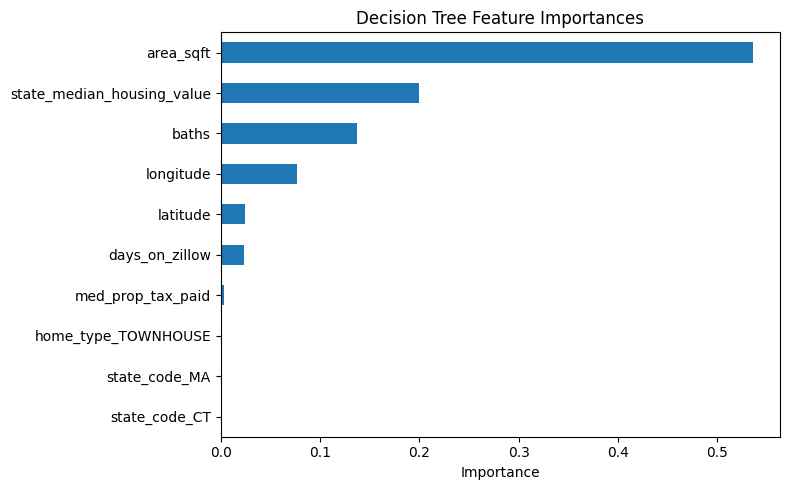

In [29]:
dt_importance = (
    pd.Series(dt_best_model.feature_importances_, index = PREDICTORS).sort_values(ascending=True) )

plt.figure(figsize=(8, 5))
dt_importance.reindex(
    dt_importance.sort_values(ascending=False).head(10).index
).sort_values().plot(kind='barh').plot(kind='barh')
plt.title("Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [30]:
# Random Forest Regressor Modeling

# RandomForestRegressor already does bootstrap sampling + feature subsetting per split.
# max_features='sqrt' matches what you were doing manually. oob_score gives a free
# validation estimate without touching the test set.

rf = (
    RandomForestRegressor(
        n_estimators = 10000,
        max_features = 'sqrt',
        min_samples_leaf = 2,
        bootstrap = True,
        oob_score = True, # 'out-of-bag' score
        n_jobs = 1,
        random_state = random_state
    )
)

rf.fit(X_train, y_train)

print("===== Random Forest Tree Information =====")
print(f'Number of Trees: {rf.n_estimators}')
print(f'Max features per split: {rf.max_features}')
print(f"OOB R^2: {rf.oob_score_:.4f}")

===== Random Forest Tree Information =====
Number of Trees: 10000
Max features per split: sqrt
OOB R^2: 0.6444


In [31]:
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf  = rf.predict(X_test)

print('===== Random Forest Metrics =====')
print()

print('Log Metrics:')
print(f'Train MSE: {mean_squared_error(y_train, y_pred_train_rf):.4f}')
print(f'Test  MSE: {mean_squared_error(y_test,  y_pred_test_rf):.4f}')
print(f'Train MAE: {mean_absolute_error(y_train, y_pred_train_rf):.4f}')
print(f'Test  MAE: {mean_absolute_error(y_test,  y_pred_test_rf):.4f}')
print(f'Train R^2: {r2_score(y_train, y_pred_train_rf):.4f}')
print(f'Test  R^2: {r2_score(y_test,  y_pred_test_rf):.4f}')

dollar_mae_train_rf = mean_absolute_error(np.exp(y_train), np.exp(y_pred_train_rf))
dollar_mae_test_rf  = mean_absolute_error(np.exp(y_test),  np.exp(y_pred_test_rf))

print()
print('Dollar Metrics:')
print(f'MAE in Dollars (Train): ${dollar_mae_train_rf:,.2f}')
print(f'MAE in Dollars (Test):  ${dollar_mae_test_rf:,.2f}')

===== Random Forest Metrics =====

Log Metrics:
Train MSE: 0.0870
Test  MSE: 0.2178
Train MAE: 0.2083
Test  MAE: 0.3255
Train R^2: 0.8330
Test  R^2: 0.6377

Dollar Metrics:
MAE in Dollars (Train): $213,889.73
MAE in Dollars (Test):  $323,146.49


In [32]:
# Tree preds running loop for plot

# number of trees
n_trees = len(rf.estimators_)

# create arrays filled with 0's to start
mse_train_seq_rf = np.zeros(n_trees)
mse_test_seq_rf  = np.zeros(n_trees)

sum_train = np.zeros(len(X_train))
sum_test  = np.zeros(len(X_test))

for b, tree_b in enumerate(rf.estimators_):
    sum_train += tree_b.predict(X_train)
    sum_test  += tree_b.predict(X_test)
    mse_train_seq_rf[b] = mean_squared_error(y_train, sum_train / (b + 1))
    mse_test_seq_rf[b]  = mean_squared_error(y_test,  sum_test  / (b + 1))

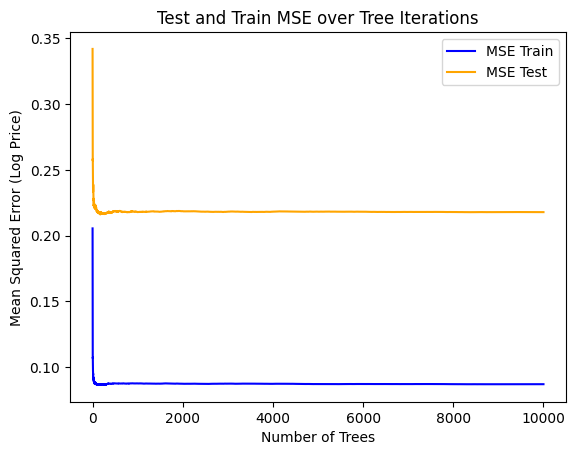

In [33]:
plt.plot(range(1, n_trees + 1), mse_train_seq_rf, label='MSE Train', c='blue')
plt.plot(range(1, n_trees + 1), mse_test_seq_rf,  label='MSE Test',  c='orange')
plt.xlabel('Number of Trees')
plt.ylabel('Mean Squared Error (Log Price)')
plt.legend()
plt.title("Test and Train MSE over Tree Iterations")
plt.show()

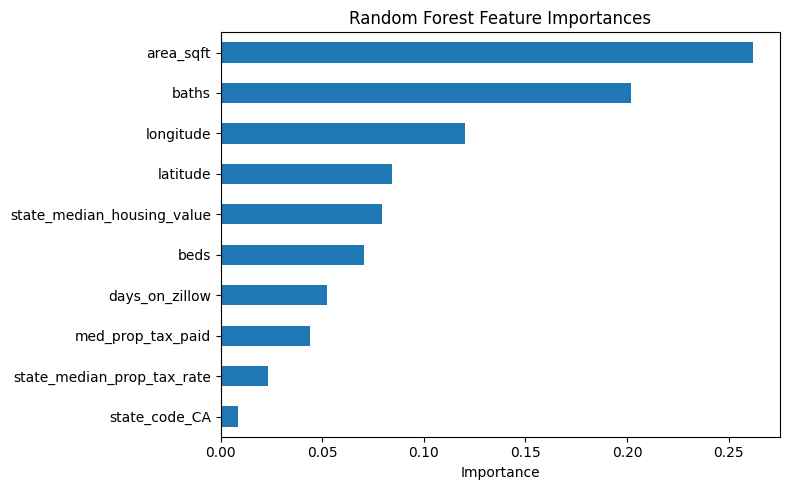

In [34]:
rf_importance = (
    pd.Series(rf.feature_importances_, index=PREDICTORS).sort_values(ascending=True) )


plt.figure(figsize=(8, 5))
rf_importance.reindex(
    rf_importance.sort_values(ascending=False).head(10).index
).sort_values().plot(kind='barh').plot(kind='barh')
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Bagging & Boosting

In [ ]:
# Bagging & Boosting
bag_base_tree = DecisionTreeRegressor(
    max_depth=12,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)

ada_base_tree = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)

bagging_model = BaggingRegressor(
    estimator=bag_base_tree,
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=1
)

adaboost_model = AdaBoostRegressor(
    estimator=ada_base_tree,
    n_estimators=300,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=RANDOM_STATE
)

bb_models = {
    "Bagging Regressor": bagging_model,
    "AdaBoost": adaboost_model,
    "Gradient Boosting": gradient_boosting_model
}

bb_results = []
bb_predictions_log = {}
bb_predictions_dollar = {}
bb_trained_models = {}

for name, model in bb_models.items():
    model.fit(X_train, y_train)

    y_pred_train_log = model.predict(X_train)
    y_pred_test_log = model.predict(X_test)

    y_pred_train_dollar = np.exp(y_pred_train_log)
    y_pred_test_dollar = np.exp(y_pred_test_log)

    y_train_dollar = np.exp(y_train)
    y_test_dollar = np.exp(y_test)

    within_15 = np.mean(np.abs(y_test_dollar - y_pred_test_dollar) / y_test_dollar <= 0.15)

    bb_results.append({
        "Model": name,
        "Train MSE (log)": mean_squared_error(y_train, y_pred_train_log),
        "Test MSE (log)": mean_squared_error(y_test, y_pred_test_log),
        "Train MAE (log)": mean_absolute_error(y_train, y_pred_train_log),
        "Test MAE (log)": mean_absolute_error(y_test, y_pred_test_log),
        "Train R2": r2_score(y_train, y_pred_train_log),
        "Test R2": r2_score(y_test, y_pred_test_log),
        "Train MSE ($)": mean_squared_error(y_train_dollar, y_pred_train_dollar),
        "Test MSE ($)": mean_squared_error(y_test_dollar, y_pred_test_dollar),
        "Train MAE ($)": mean_absolute_error(y_train_dollar, y_pred_train_dollar),
        "Test MAE ($)": mean_absolute_error(y_test_dollar, y_pred_test_dollar),
        "Within 15% Accuracy": within_15
    })

    bb_predictions_log[name] = y_pred_test_log
    bb_predictions_dollar[name] = y_pred_test_dollar
    bb_trained_models[name] = model

bb_results_df = pd.DataFrame(bb_results).sort_values("Test MAE ($)").reset_index(drop=True)
bb_results_df

,Model,Train MSE (log),Test MSE (log),Train MAE (log),Test MAE (log),Train R2,Test R2,Train MSE ($),Test MSE ($),Train MAE ($),Test MAE ($),Within 15% Accuracy
0,Gradient Boosting,0.089005,0.191486,0.225012,0.309142,0.829077,0.681492,2.744563e+11,1.409627e+12,175734.457037,298704.097172,0.338983
1,Bagging Regressor,0.064837,0.201527,0.179095,0.312637,0.875490,0.664789,4.743915e+11,1.404417e+12,171892.449059,306160.036821,0.368039
2,AdaBoost,0.167440,0.236065,0.320431,0.357011,0.678453,0.607341,5.531757e+11,1.434114e+12,258356.658622,331616.672958,0.295400


In [ ]:
# Results table

bb_results_display = bb_results_df.copy()

for col in ["Train MSE ($)", "Test MSE ($)", "Train MAE ($)", "Test MAE ($)"]:
    bb_results_display[col] = bb_results_display[col].map(lambda x: f"${x:,.2f}")

for col in ["Train MSE (log)", "Test MSE (log)", "Train MAE (log)", "Test MAE (log)", "Train R2", "Test R2"]:
    bb_results_display[col] = bb_results_display[col].map(lambda x: f"{x:.4f}")

bb_results_display["Within 15% Accuracy"] = bb_results_df["Within 15% Accuracy"].map(lambda x: f"{x*100:.2f}%")
bb_results_display

,Model,Train MSE (log),Test MSE (log),Train MAE (log),Test MAE (log),Train R2,Test R2,Train MSE ($),Test MSE ($),Train MAE ($),Test MAE ($),Within 15% Accuracy
0,Gradient Boosting,0.0890,0.1915,0.2250,0.3091,0.8291,0.6815,"$274,456,283,597.93","$1,409,626,589,736.44","$175,734.46","$298,704.10",33.90%
1,Bagging Regressor,0.0648,0.2015,0.1791,0.3126,0.8755,0.6648,"$474,391,543,935.61","$1,404,417,091,259.27","$171,892.45","$306,160.04",36.80%
2,AdaBoost,0.1674,0.2361,0.3204,0.3570,0.6785,0.6073,"$553,175,714,285.75","$1,434,113,836,641.27","$258,356.66","$331,616.67",29.54%


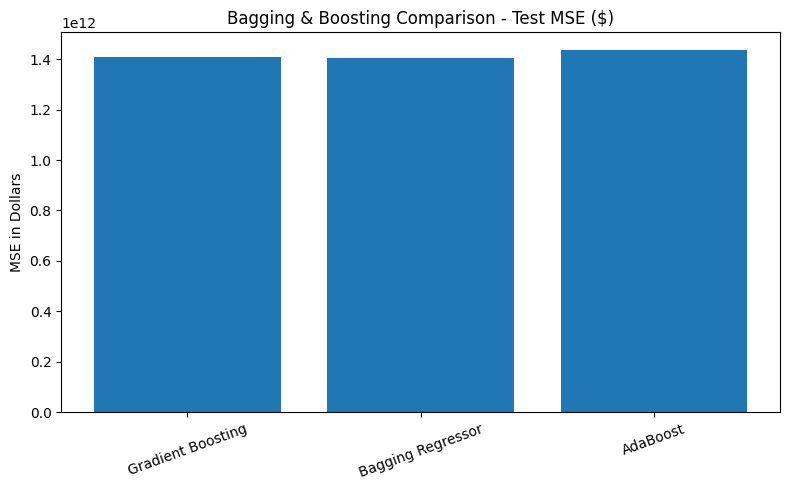

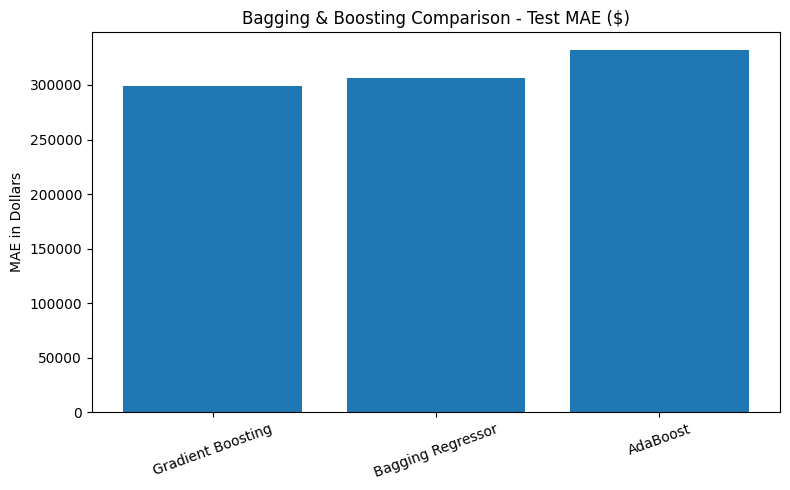

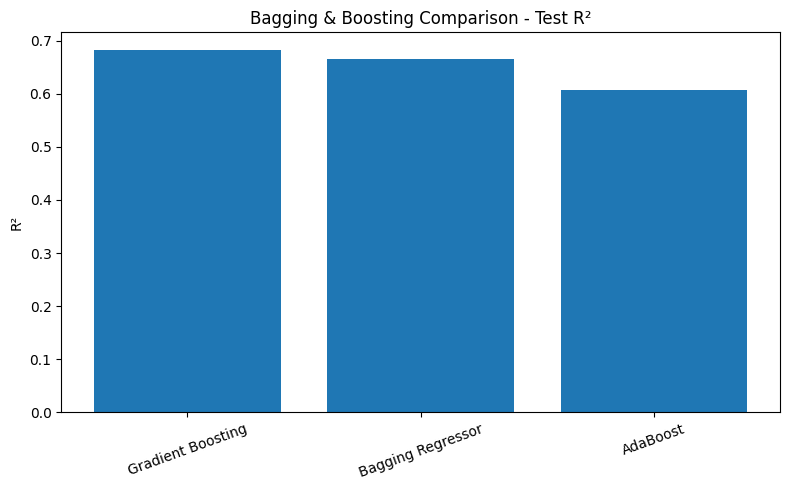

In [38]:
# Comparison plots
plt.figure(figsize=(8, 5))
plt.bar(bb_results_df["Model"], bb_results_df["Test MSE ($)"])
plt.title("Bagging & Boosting Comparison - Test MSE ($)")
plt.ylabel("MSE in Dollars")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(bb_results_df["Model"], bb_results_df["Test MAE ($)"])
plt.title("Bagging & Boosting Comparison - Test MAE ($)")
plt.ylabel("MAE in Dollars")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(bb_results_df["Model"], bb_results_df["Test R2"])
plt.title("Bagging & Boosting Comparison - Test R²")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [39]:
# Best model and sample predictions in normal dollar format

bb_best_model_name = bb_results_df.loc[0, "Model"]
bb_best_model = bb_trained_models[bb_best_model_name]
bb_best_predictions_log = bb_best_model.predict(X_test)
bb_best_predictions_dollar = np.exp(bb_best_predictions_log)

print("Best Bagging/Boosting model:", bb_best_model_name)

bb_comparison_df = pd.DataFrame({
    "Actual Price": np.exp(y_test),
    "Predicted Price": bb_best_predictions_dollar
})

bb_comparison_display = bb_comparison_df.copy()
bb_comparison_display["Actual Price"] = bb_comparison_display["Actual Price"].map(lambda x: f"${x:,.0f}")
bb_comparison_display["Predicted Price"] = bb_comparison_display["Predicted Price"].map(lambda x: f"${x:,.0f}")

bb_comparison_display.head(15)

Best Bagging/Boosting model: Gradient Boosting


,Actual Price,Predicted Price
1355,"$735,000","$456,744"
1999,"$585,000","$273,840"
1357,"$889,000","$549,856"
1348,"$330,000","$373,891"
30,"$1,299,000","$746,566"
1410,"$190,000","$348,665"
1702,"$19,995,000","$546,202"
1025,"$880,000","$720,416"
627,"$750,000","$547,278"
779,"$399,900","$359,203"


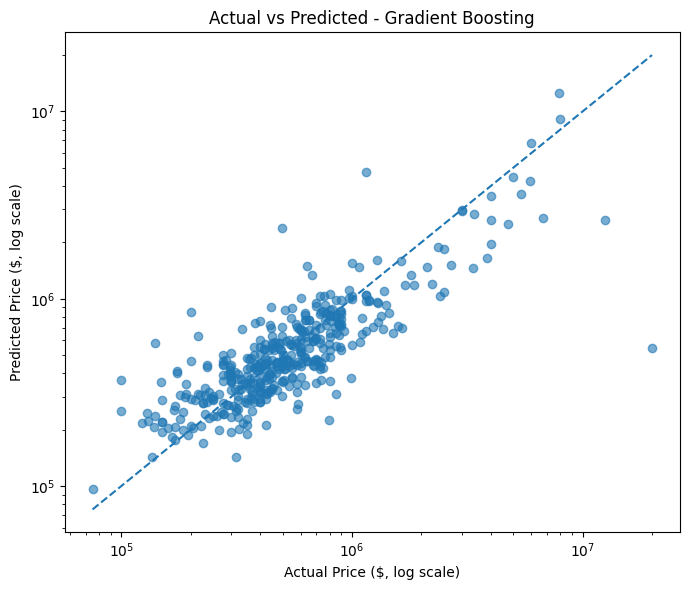

In [40]:
# Actual vs Predicted plot for the best model

plt.figure(figsize=(7, 6))
plt.scatter(np.exp(y_test), bb_best_predictions_dollar, alpha=0.6)

min_val = min(np.exp(y_test).min(), bb_best_predictions_dollar.min())
max_val = max(np.exp(y_test).max(), bb_best_predictions_dollar.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual Price ($, log scale)")
plt.ylabel("Predicted Price ($, log scale)")
plt.title(f"Actual vs Predicted - {bb_best_model_name}")
plt.tight_layout()
plt.show()

##### Neural Network

In [41]:
# Check if cuda is available - ran on Google Colab originally using A100 GPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

NameError: name 'torch' is not defined

###### Define Dataset and Neural Network class

Custom Dataset to use with Training/Testing DataLoader classes when actually training the model.

HousePriceNN is just a simple feedforwards Neural Net with a single output for the predicted house value (since it is not a classification problem).

In [ ]:
class ZillowDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Define the Regression Model
class HousePriceNN(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

###### Hyperparameter, feature testing, and 5-fold cross validation

Testing a small grid search on possible epoch training and learning rate values.

This could be much further extended, especially for learning rate but for the sake of this project was kept pretty simple to explore some values.

Additionally, 5-folds cross validation (using the built in sklearn KFold library) was chosen just simply based on the heuristic that 5 or 10 are generally good working values and 10 would add more time to training.

This exact same training loop is used for both the models that are optimized for MSE and MAE below

###### Fit best model using MSE as Criterion

Since we used both MSE and MAE as our evaluation metrics in previous models, we also want to try fitting the same neural network model using both metrics as our loss function to optimize for.

First up is a model that uses MSE as the loss function for training.

In [ ]:
epochs_grid = [10, 20, 30, 40, 50]
lr_grid = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
batch_size = 32
k_folds = 5

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

best_avg_loss = float('inf')
best_params = {}
grid_results = []

print("Starting Grid Search...")

# Define the single feature set for the Neural Network, using the already scaled training features
X_nn_train = X_train_sc
y_nn_train = y_train # y_train is already log-transformed

# Determine input features count for the NN model
input_features_count = X_nn_train.shape[1]

for lr, epochs in itertools.product(lr_grid, epochs_grid):
    fold_losses = []
    print(f"\nTesting lr={lr}, epochs={epochs}...")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_nn_train)):
        X_fold_train, y_fold_train = X_nn_train[train_idx], y_nn_train.iloc[train_idx]
        X_fold_val, y_fold_val = X_nn_train[val_idx], y_nn_train.iloc[val_idx]

        train_dataset = ZillowDataset(X_fold_train, y_fold_train.values.reshape(-1, 1))
        val_dataset = ZillowDataset(X_fold_val, y_fold_val.values.reshape(-1, 1))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = HousePriceNN(input_features=input_features_count).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        model.train()
        for epoch in range(epochs):
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                val_loss += criterion(model(batch_X), batch_y).item() * batch_X.size(0)

        fold_losses.append(val_loss / len(val_loader.dataset))

    avg_loss = sum(fold_losses) / k_folds

    print(f"Fold Losses: {fold_losses}")
    print(f"Average Loss: {avg_loss:.4f}")
    grid_results.append({'lr': lr, 'epochs': epochs, 'val_loss': avg_loss})

    if avg_loss < best_avg_loss:
        best_avg_loss = avg_loss
        best_params = {'lr': lr, 'epochs': epochs}

print(f"\nBest Params: lr={best_params['lr']}, epochs={best_params['epochs']} (Loss: {best_avg_loss:.4f})")

In [ ]:
# Check best hyperparam combos for MSE model
df_results = pd.DataFrame(grid_results)
df_results.sort_values('val_loss').head(10)

Based on the grid search, a learning rate of 0.01 and 50 epochs seemed to do the best on average with the 5-fold cross validation. These are the values we will use for the final testing set, while still acknowledging that due to the simple nature of this model and the lack of deep exploration into all feature combinations, better performing combinations will almost surely exist.

Next, we fit a model using the best hyperparameters from the grid search that used MSE as the loss function.

In [ ]:
# Get the best configuration
best_epochs = best_params['epochs']
best_lr = best_params['lr']

final_train_dataset = ZillowDataset(X_train_sc, y_train.values.reshape(-1, 1))
test_dataset = ZillowDataset(X_test_sc, y_test.values.reshape(-1, 1))

final_train_loader = DataLoader(final_train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

final_model = HousePriceNN(input_features=input_features_count).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
criterion = nn.MSELoss()

train_losses = []
test_losses = []

print(f"Training final model with lr={best_lr}, epochs={best_epochs}...")
for epoch in range(best_epochs):
    # Training
    final_model.train()
    epoch_train_loss = 0
    for batch_X, batch_y in final_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        preds = final_model(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)

    train_losses.append(epoch_train_loss / len(final_train_dataset))

    # Testing per epoch
    final_model.eval()
    epoch_test_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            preds = final_model(batch_X)
            loss = criterion(preds, batch_y)
            epoch_test_loss += loss.item() * batch_X.size(0)

    test_losses.append(epoch_test_loss / len(test_dataset))


# Final RMSE calculation
final_model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        all_preds.append(final_model(batch_X).cpu().numpy())
        all_targets.append(batch_y.cpu().numpy())

# Convert log-transformed predictions and targets back to dollar values
preds_dollars = np.exp(np.vstack(all_preds))
targets_dollars = np.exp(np.vstack(all_targets))
rmse_dollars = np.sqrt(mean_squared_error(targets_dollars, preds_dollars))
print(f"\nFinal Test RMSE in Dollars: ${rmse_dollars:,.2f}")

# Save the best MAE model weights
torch.save(final_model_mae.state_dict(), 'best_zillow_model_mse.pth')
print("MAE Model saved to 'best_zillow_model_mse.pth'")

###### Fit best model using MAE as Criterion

For comparison, next we will fit a model using the same grid search setup with the only difference being MAE is used as the Criterion for optimizing.

In [ ]:
# Grid search for MAE optimized model
epochs_grid = [10, 20, 30, 40, 50]
lr_grid = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
batch_size = 32
k_folds = 5

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

best_avg_loss_mae = float('inf')
best_params_mae = {}
grid_results_mae = []

print("Starting Grid Search for MAE model...")

for lr, epochs in itertools.product(lr_grid, epochs_grid):
    fold_losses_mae = []
    print(f"\nTesting lr={lr}, epochs={epochs}...")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_nn_train)):
        X_fold_train, y_fold_train = X_nn_train[train_idx], y_nn_train.iloc[train_idx]
        X_fold_val, y_fold_val = X_nn_train[val_idx], y_nn_train.iloc[val_idx]

        train_dataset = ZillowDataset(X_fold_train, y_fold_train.values.reshape(-1, 1))
        val_dataset = ZillowDataset(X_fold_val, y_fold_val.values.reshape(-1, 1))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model_mae = HousePriceNN(input_features=input_features_count).to(device)
        criterion_mae = nn.L1Loss() # L1Loss = MAE in PyTorch
        optimizer_mae = optim.Adam(model_mae.parameters(), lr=lr)

        model_mae.train()
        for epoch in range(epochs):
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer_mae.zero_grad()
                loss = criterion_mae(model_mae(batch_X), batch_y)
                loss.backward()
                optimizer_mae.step()

        model_mae.eval()
        val_loss_mae = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                val_loss_mae += criterion_mae(model_mae(batch_X), batch_y).item() * batch_X.size(0)

        fold_losses_mae.append(val_loss_mae / len(val_loader.dataset))

    avg_loss_mae = sum(fold_losses_mae) / k_folds

    print(f"Fold Losses MAE: {fold_losses_mae}")
    print(f"Average Loss MAE: {avg_loss_mae:.4f}")
    grid_results_mae.append({'lr': lr, 'epochs': epochs, 'val_loss_mae': avg_loss_mae})

    if avg_loss_mae < best_avg_loss_mae:
        best_avg_loss_mae = avg_loss_mae
        best_params_mae = {'lr': lr, 'epochs': epochs}

print(f"\nBest Params MAE: lr={best_params_mae['lr']}, epochs={best_params_mae['epochs']} (Loss: {best_avg_loss_mae:.4f})")

In [ ]:
# Check best hyperparam combos for MAE model
df_maeresults = pd.DataFrame(grid_results_mae)
df_maeresults.sort_values('val_loss_mae').head(10)

After doing grid search on the MAE model, the best parameter combination appears to be lr = .15 with 20 epochs, not too different from the MSE model which had the same best lr but 50 epochs instead.

Furthermore, the losses for 20 and 30 epochs with lr = .15 are quite close together, indicating a pretty trivial difference between one or the other in this case, so we will just go with the best.

In [ ]:
# Get the best configuration for MAE model
best_epochs_mae = best_params_mae['epochs']
best_lr_mae = best_params_mae['lr']
input_features_count_mae = best_params_mae['input_features_count']

final_train_dataset_mae = ZillowDataset(X_train_sc, y_train.values.reshape(-1, 1))
test_dataset_mae = ZillowDataset(X_test_sc, y_test.values.reshape(-1, 1))

final_train_loader_mae = DataLoader(final_train_dataset_mae, batch_size=batch_size, shuffle=True)
test_loader_mae = DataLoader(test_dataset_mae, batch_size=batch_size, shuffle=False)

final_model_mae = HousePriceNN(input_features=input_features_count_mae).to(device)
optimizer_mae = optim.Adam(final_model_mae.parameters(), lr=best_lr_mae)
criterion_mae = nn.L1Loss() # Use MAE Loss for final model

train_losses_mae = []
test_losses_mae = []

print(f"Training final MAE model with lr={best_lr_mae}, epochs={best_epochs_mae}...")
for epoch in range(best_epochs_mae):
    # Training
    final_model_mae.train()
    epoch_train_loss_mae = 0
    for batch_X, batch_y in final_train_loader_mae:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer_mae.zero_grad()
        preds_mae = final_model_mae(batch_X)
        loss_mae = criterion_mae(preds_mae, batch_y)
        loss_mae.backward()
        optimizer_mae.step()
        epoch_train_loss_mae += loss_mae.item() * batch_X.size(0)

    train_losses_mae.append(epoch_train_loss_mae / len(final_train_dataset_mae))

    # Testing per epoch
    final_model_mae.eval()
    epoch_test_loss_mae = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader_mae:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            preds_mae = final_model_mae(batch_X)
            loss_mae = criterion_mae(preds_mae, batch_y)
            epoch_test_loss_mae += loss_mae.item() * batch_X.size(0)

    test_losses_mae.append(epoch_test_loss_mae / len(test_dataset_mae))


# Final RMSE calculation for MAE model
final_model_mae.eval()
all_preds_mae = []
all_targets_mae = []
with torch.no_grad():
    for batch_X, batch_y in test_loader_mae:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        all_preds_mae.append(final_model_mae(batch_X).cpu().numpy())
        all_targets_mae.append(batch_y.cpu().numpy())

# Convert log-transformed predictions and targets back to dollar values using np.exp
preds_dollars_mae = np.exp(np.vstack(all_preds_mae))
targets_dollars_mae = np.exp(np.vstack(all_targets_mae))
rmse_dollars_mae = np.sqrt(mean_squared_error(targets_dollars_mae, preds_dollars_mae))
print(f"\nFinal Test RMSE in Dollars (MAE Model): ${rmse_dollars_mae:,.2f}")

# Save the best MAE model weights
torch.save(final_model_mae.state_dict(), 'best_zillow_model_mae.pth')
print("MAE Model saved to 'best_zillow_model_mae.pth'")

###### MSE Model: Train/Test Loss Curves

In [ ]:
# Plot train/test loss over epochs for the MSE model
plt.figure(figsize=(10, 6))

plt.plot(range(1, best_epochs + 1), train_losses, label='MSE Train Loss', color='orange', linestyle='-')
plt.plot(range(1, best_epochs + 1), test_losses, label='MSE Test Loss', color='blue', linestyle='-')

plt.xlabel('Epochs')
plt.ylabel('Loss (Scaled)')
plt.title('MSE Model: Train/Test Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sorted(test_losses)

###### MAE Model: Train/Test Loss Curves

In [ ]:
# Plot train/test loss over epochs for the MAE model
plt.figure(figsize=(10, 6))

plt.plot(range(1, best_epochs_mae + 1), train_losses_mae, label='MAE Train Loss', color='orange', linestyle='-')
plt.plot(range(1, best_epochs_mae + 1), test_losses_mae, label='MAE Test Loss', color='blue', linestyle='-')

plt.xlabel('Epochs')
plt.ylabel('Loss (Scaled)')
plt.title('MAE Model: Train/Test Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sorted(test_losses_mae)

Both models are able to reach a stable training and test loss after about 10 epochs, from there the gains are extremely marginal, especially for the MSE model. It really did not need 50 epochs; even though that was the "best" performing model in the grid-search, it was trivially different from one that could be trained with 10 epochs.

The MSE model had a final RMSE on the full test data set of 1,286,591.82 while the MAE model had RMSE of 1,242,502.11. So with this metric, we do see slightly better overall predictions from the model that was optimized using the MAE/L1 loss function, with an improvement of about $40,000 in terms of RMSE.

###### Making final predictions on the complete dataset

Since the MAE model performed slightly better, we can use it now to make predictions on the whole dataset and see how they look in terms of dollars against the actual values.

In [ ]:
# Save version of full dataset with only the features used in the final model.
# Use the original X (before train-test split, after one-hot encoding) and scale it using the previously fitted scaler
X_full = X # This 'X' is the one created in cell 14abe4f1, after get_dummies but before train-test split
X_full_scaled = scaler.transform(X_full) # 'scaler' was fit on X_train_sc in cell 7e4512dc

# Convert to PyTorch tensor
X_full_tensor = torch.tensor(X_full_scaled, dtype=torch.float32).to(device)

# Predict prices for all houses in the data
final_model_mae.eval()
with torch.no_grad():
    preds_full_log_scaled = final_model_mae(X_full_tensor).cpu().numpy()

# Undo log transformation to get actual dollar values.
preds_full_dollars = np.exp(preds_full_log_scaled)

# Create comparison for actual vs. predicted price
df_comparison = pd.DataFrame({
    'Actual Price': df_filtered['price'].values, # Use the original df_filtered price
    'Predicted Price': preds_full_dollars.flatten()
})
df_comparison['Difference'] = df_comparison['Actual Price'] - df_comparison['Predicted Price']

display(df_comparison.head(15))